In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from floorplans.lidar.lidar import Lidar2D, OnlineTrajectoryLidarDataset
import glob
import numpy as np
import os

In [3]:
# Settings
data_dir = "./32_data"
waypoint_subdir = "minimal_overlap"
img_path = os.path.join(data_dir, "floor_img.png")
num_beams = 20
beam_samps = 25
beam_length = 0.2
spline_res = 30
samp_distribution_factor = 1.0
collision_samps = 50
fine_samps = 3
num_scans_in_window = 30
spline_res = 30


# Setup Lidar Object
lidar = Lidar2D(img_path, num_beams, beam_length, beam_samps,
    samp_distribution_factor, collision_samps, fine_samps, border_width=30)

# Waypoint Settings
wp_names = glob.glob1(os.path.join(data_dir, waypoint_subdir), "*.npy") 

datasets = []
for wp_name in wp_names:
    wp_path = os.path.join(data_dir, waypoint_subdir, wp_name)
    wps = np.load(wp_path)
    ds = OnlineTrajectoryLidarDataset(lidar, wps, 
        spline_res, num_scans_in_window)
    datasets.append(ds)
    
tight_paths_waypoint_subdir="tight_paths"
t_wp_names = glob.glob1(os.path.join(data_dir, tight_paths_waypoint_subdir), "*.npy") 
t_datasets = []
for wp_name in t_wp_names:
    wp_path = os.path.join(data_dir, tight_paths_waypoint_subdir, wp_name)
    wps = np.load(wp_path)
    ds = OnlineTrajectoryLidarDataset(lidar, wps, 
        spline_res, num_scans_in_window)
    t_datasets.append(ds)

In [4]:
# 获取默认颜色循环
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
# 打印默认颜色数组
print(default_colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [5]:
# ax.plot(datasets[0].scan_locs[:, 0], datasets[0].scan_locs[:, 1],
#     c="orangered", alpha=0.3, zorder=3)
# scan_points = datasets[0].scans[:datasets[0].scan_size, :]
# ld_points = scan_points[scan_points[:, 2] != 1.0]
# hd_points = scan_points[scan_points[:, 2] == 1.0]
# ax.scatter(ld_points[:, 0], ld_points[:, 1], s=5, color="darkblue", alpha=0.4, zorder=2)
# ax.scatter(hd_points[:, 0], hd_points[:, 1], s=15, color="gold", alpha=1.0, zorder=2)
# init_loc=np.array([[datasets[0].scan_locs[0, 0], datasets[0].scan_locs[0, 1]]])

Text(0.5, 1.0, '低异构性场景')

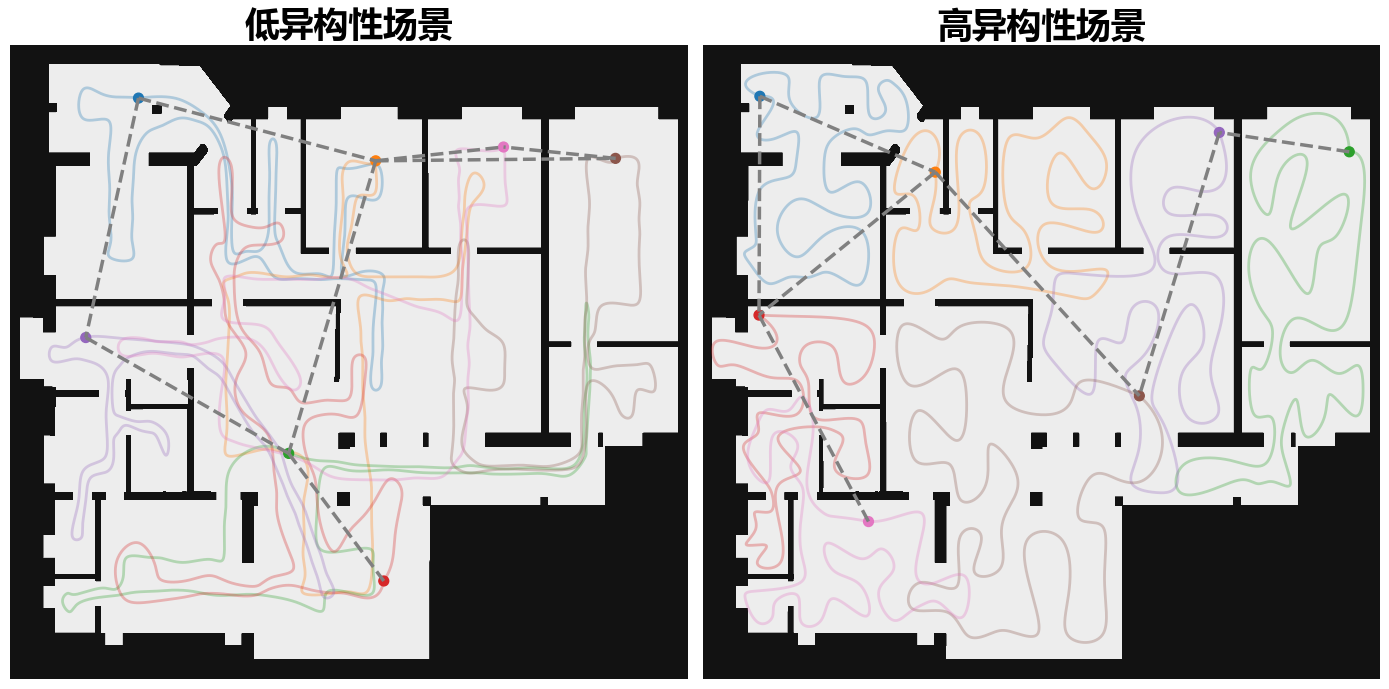

In [6]:
(fig, axs) = plt.subplots(1,2,figsize=(14,7),tight_layout=True)
ax0=axs[0]
ax=axs[1]
X, Y = np.meshgrid(lidar.xs, lidar.ys)
ax.contourf(X, Y, lidar.img, cmap=cm.binary, zorder=0)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
init_loc=np.empty((0, 2))
for ds in datasets:
    ax.plot(ds.scan_locs[:, 0], ds.scan_locs[:, 1], alpha=0.3,linewidth=2, zorder=1)
    init_loc = np.vstack((init_loc, [[ds.scan_locs[0, 0], ds.scan_locs[0, 1]]]))
    # print(len(ds))
ax.scatter(init_loc[:, 0], init_loc[:, 1], s=50, color=default_colors[:7], zorder=2)
for i in range(init_loc.shape[0]):
    for j in range(i+1,init_loc.shape[0]):
        if i == j:
            continue
        else:
            distance=np.sqrt(np.sum(np.square(init_loc[i]-init_loc[j])))
            if(distance<=900):
                #draw a line between two points
                ax.plot([init_loc[i, 0], init_loc[j, 0]], [init_loc[i, 1], init_loc[j, 1]],alpha=1, c="grey",linewidth=2.5,linestyle='--')
ax.set_axis_off()
# ax.set_title("High-Heterogeneity",fontsize=25)
ax.set_title("高异构性场景",fontsize=25,fontweight='bold')

ax0.contourf(X, Y, lidar.img, cmap=cm.binary, zorder=0)
t_init_loc=np.empty((0, 2))
for ds in t_datasets:
    ax0.plot(ds.scan_locs[:, 0], ds.scan_locs[:, 1], alpha=0.3,linewidth=2, zorder=1)
    t_init_loc = np.vstack((t_init_loc, [[ds.scan_locs[0, 0], ds.scan_locs[0, 1]]]))
    # print(len(ds))
ax0.scatter(t_init_loc[:, 0], t_init_loc[:, 1], s=50, color=default_colors[:7], zorder=2)
for i in range(t_init_loc.shape[0]):
    for j in range(i+1,t_init_loc.shape[0]):
        if i == j:
            continue
        else:
            distance=np.sqrt(np.sum(np.square(t_init_loc[i]-t_init_loc[j])))
            if(distance<=900):
                #draw a line between two points
                ax0.plot([t_init_loc[i, 0], t_init_loc[j, 0]], [t_init_loc[i, 1], t_init_loc[j, 1]],alpha=1, c="grey",linewidth=2.5,linestyle='--')
ax0.set_axis_off()
# ax0.set_title("Low-Heterogeneity",fontsize=25)
ax0.set_title("低异构性场景",fontsize=25,fontweight='bold')
# fig.savefig("hard_easy.png",dpi=1000)
# fig.savefig("high_low.png",dpi=300)


In [1]:
fig.savefig("tight_paths.png", dpi=500.0)

NameError: name 'fig' is not defined